# Phase 4: Evaluate the Simple CNN

In this phase we evaluate the trained model on the test set. The test set was not used for training or validation, so it gives the fairest estimate of model performance.

We will calculate accuracy, precision, recall, F1 score, and a confusion matrix.

## 1. Setup

Import PyTorch, project utilities, and evaluation helpers. Finds the project root, uses CPU, and points to the final Phase 3 checkpoint.

In [1]:
import sys
from pathlib import Path

from IPython.display import display
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from spectiqai.data import KidneyImageDataset, count_by_class, load_split_csv
from spectiqai.evaluation import (
    binary_classification_metrics,
    collect_predictions,
    create_confusion_matrix_image,
    save_metrics_csv,
    save_predictions_csv,
)
from spectiqai.models import SimpleKidneyCNN

DEVICE = torch.device("cpu")
SPLIT_CSV_PATH = PROJECT_ROOT / "results" / "dataset_splits.csv"
CHECKPOINT_PATH = PROJECT_ROOT / "models" / "simple_cnn" / "simple_cnn_epoch_3.pt"
RESULTS_DIR = PROJECT_ROOT / "results"

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")
print(f"Checkpoint path: {CHECKPOINT_PATH}")
print(f"Checkpoint exists: {CHECKPOINT_PATH.exists()}")

Project root: c:\Users\smart\Coding World\SpectiqAI
Device: cpu
Checkpoint path: c:\Users\smart\Coding World\SpectiqAI\models\simple_cnn\simple_cnn_epoch_3.pt
Checkpoint exists: True


We can load the trained model from Phase 3. Next step: load the test split.

## 2. Load Test Data

Evaluate only on the test set. Loads the saved Phase 2 split, selects the test records, resizes images to 224 x 224, and creates a DataLoader.

In [2]:
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0

splits = load_split_csv(SPLIT_CSV_PATH, project_root=PROJECT_ROOT)
test_records = splits["test"]

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

test_dataset = KidneyImageDataset(test_records, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Test images: {len(test_dataset)}")
print(f"Test class counts: {count_by_class(test_records)}")
print(f"Test batches: {len(test_loader)}")

Test images: 1500
Test class counts: {'Normal': 750, 'Tumor': 750}
Test batches: 94


The final evaluation will use unseen data. Next step: load the trained model checkpoint.

## 3. Load the Trained Model

Restore the CNN weights learned during Phase 3. Creates the same CNN architecture and loads the saved checkpoint weights.

In [3]:
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")

model = SimpleKidneyCNN(num_classes=2).to(DEVICE)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Loaded checkpoint epoch: {checkpoint['epoch']}")
print(f"Saved validation metrics: {checkpoint['metrics']}")

Loaded checkpoint epoch: 3
Saved validation metrics: {'epoch': 3, 'train_loss': 0.07220970629528164, 'train_accuracy': 0.9754285714285714, 'val_loss': 0.025610201369971036, 'val_accuracy': 0.9886666666666667}


The model is ready to make test predictions. Next step: collect predictions.

## 4. Collect Test Predictions

Run the model on every test image. Stores true labels, predicted labels, and tumor probabilities.

In [4]:
true_labels, predicted_labels, tumor_probabilities = collect_predictions(model, test_loader, DEVICE)

print(f"True labels: {len(true_labels)}")
print(f"Predicted labels: {len(predicted_labels)}")
print(f"First 10 predictions: {predicted_labels[:10]}")

True labels: 1500
Predicted labels: 1500
First 10 predictions: [1, 0, 0, 0, 1, 1, 0, 0, 0, 1]


Every test image has a model prediction. Next step: calculate metrics.

## 5. Calculate Evaluation Metrics

Summarize model performance with standard classification metrics.

In [5]:
metrics = binary_classification_metrics(true_labels, predicted_labels)

for metric_name, metric_value in metrics.items():
    if metric_name in {"accuracy", "precision", "recall", "f1_score"}:
        print(f"{metric_name}: {metric_value:.4f}")
    else:
        print(f"{metric_name}: {int(metric_value)}")

accuracy: 0.9893
precision: 0.9791
recall: 1.0000
f1_score: 0.9894
true_positive: 750
true_negative: 734
false_positive: 16
false_negative: 0


These numbers describe final performance on unseen test images. Next step: visualize the confusion matrix and save results.

## 6. Save Metrics and Confusion Matrix

Save evaluation outputs for the final report. Writes metrics, per-image predictions, and a confusion matrix image into the `results` folder.

Saved metrics: c:\Users\smart\Coding World\SpectiqAI\results\simple_cnn_test_metrics.csv
Saved predictions: c:\Users\smart\Coding World\SpectiqAI\results\simple_cnn_test_predictions.csv
Saved confusion matrix: c:\Users\smart\Coding World\SpectiqAI\results\simple_cnn_confusion_matrix.png


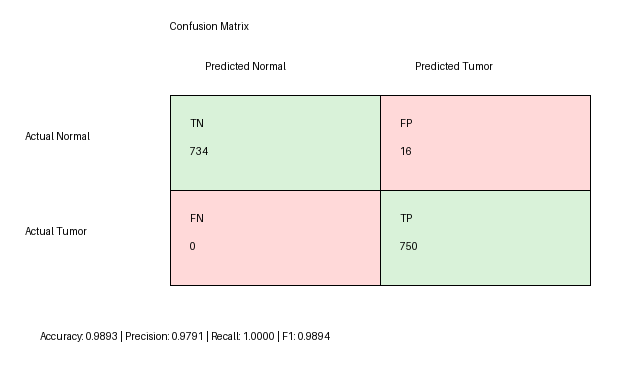

In [6]:
metrics_path = RESULTS_DIR / "simple_cnn_test_metrics.csv"
predictions_path = RESULTS_DIR / "simple_cnn_test_predictions.csv"
confusion_matrix_path = RESULTS_DIR / "simple_cnn_confusion_matrix.png"

save_metrics_csv(metrics, metrics_path)
save_predictions_csv(true_labels, predicted_labels, tumor_probabilities, predictions_path)
confusion_matrix_image = create_confusion_matrix_image(metrics, confusion_matrix_path)

print(f"Saved metrics: {metrics_path}")
print(f"Saved predictions: {predictions_path}")
print(f"Saved confusion matrix: {confusion_matrix_path}")
display(confusion_matrix_image)

Phase 4 is complete for the simple CNN. Next step: phase 5 compares this CNN with transfer learning models like ResNet50 and EfficientNetB0.